In [84]:
import math
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Polygon
import numpy as np


def triangular_lattice_positions(Lx, Ly):
    pos = {}
    for i in range(Lx):
        for j in range(Ly):
            x = i + 0.5 * j
            y = (math.sqrt(3) / 2.0) * j
            pos[(i, j)] = (x, y)
    return pos

def triangular_spin_graph(Lx, Ly):
    G = nx.Graph()
    for i in range(Lx):
        for j in range(Ly):
            G.add_node((i, j))

    # triangular-lattice nearest neighbors
    for i in range(Lx):
        for j in range(Ly):
            for di, dj in [(1, 0), (0, 1), (1, -1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < Lx and 0 <= nj < Ly:
                    G.add_edge((i, j), (ni, nj))
    return G

def nm_check_vertices(i, j):
    # Newman-Moore right-pointing check
    return [(i, j), (i + 1, j), (i , j + 1)]

def draw_nm(
    Lx=6,
    Ly=5,
    error_qubits=None,
    violated_checks=None,
    label=False,
):
    if error_qubits is None:
        error_qubits = set()
    if violated_checks is None:
        violated_checks = set()

    G = triangular_spin_graph(Lx, Ly)
    pos = triangular_lattice_positions(Lx, Ly)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    # base lattice
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.2, alpha=0.45)

    # all qubits as light circles
    all_nodes = list(G.nodes)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=all_nodes,
        ax=ax,
        node_size=280,
        node_color="white",
        edgecolors="black",
        linewidths=1.0,
    )

    # violated stabilizers as shaded triangles
    for (i, j) in violated_checks:
        verts = nm_check_vertices(i, j)
        if all(v in pos for v in verts):
            poly_xy = [pos[v] for v in verts]
            patch = Polygon(
                poly_xy,
                closed=True,
                facecolor="black",
                edgecolor="black",
                alpha=0.18,
                linewidth=2.0,
                zorder=2,
            )
            ax.add_patch(patch)

    # qubit errors as shaded dots
    if error_qubits:
        err_xy = [pos[v] for v in error_qubits if v in pos]
        ax.scatter(
            [p[0] for p in err_xy],
            [p[1] for p in err_xy],
            s=430,              # slightly larger than base node
            c="gray",
            alpha=0.4,         # shading
            linewidths=0,
            zorder=3,
        )
        ax.scatter(
            [p[0] for p in err_xy],
            [p[1] for p in err_xy],
            s=280,              # redraw crisp boundary
            facecolors="none",
            edgecolors="black",
            linewidths=1.6,
            zorder=4,
        )

    # redraw qubit centers so nodes stay crisp over triangle fills
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=all_nodes,
        ax=ax,
        node_size=280,
        node_color="white",
        edgecolors="black",
        linewidths=1.0,
    )

    # then redraw the error dots once more on top
    if error_qubits:
        ax.scatter(
            [pos[v][0] for v in error_qubits if v in pos],
            [pos[v][1] for v in error_qubits if v in pos],
            s=190,
            c="black",
            alpha=0.45,
            linewidths=0,
            zorder=5,
        )
        # tag labels 
        nx.draw_networkx_labels(
            G,
            pos,    
            labels={v: str(k) for k, v in enumerate(error_qubits, start=1)},
            font_size=10,
            ax=ax,
            font_color='blue'
        )   

    if label:
        nx.draw_networkx_labels(
            G, pos, ax=ax,
            labels={v: f"{v}" for v in G.nodes},
            font_size=8
        )

    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    return fig, ax



In [5]:

def bit_array_to_sites(arr, swap_rc_to_ij=True):
    """
    Convert a 2D 0/1 array into a set of lattice sites.

    Parameters
    ----------
    arr : array-like, shape (nrows, ncols)
        Binary array with 1 marking an occupied/error site.
    swap_rc_to_ij : bool
        If True, interpret arr[row, col] as lattice site (col, row).
        If False, interpret arr[i, j] directly as site (i, j).

    Returns
    -------
    sites : set of tuple[int, int]
        Set of lattice coordinates.
    """
    arr = np.asarray(arr)
    coords = np.argwhere(arr == 1)   # each entry is [row, col]

    if swap_rc_to_ij:
        return {(int(c), int(r)) for r, c in coords}
    else:
        return {(int(r), int(c)) for r, c in coords}
    
def pascal_mod2_rows(num_rows: int, width: int | None = None) -> np.ndarray:
    """
    Build rows of (1+x)^n over GF(2).

    Output A has shape (num_rows, width), where
    A[n, k] = 1 iff coeff of x^k in (1+x)^n is 1 mod 2.
    """
    if width is None:
        width = num_rows

    A = np.zeros((num_rows, width), dtype=np.uint8)
    A[0, 0] = 1   # (1+x)^0 = 1

    for n in range(num_rows - 1):
        row = A[n]
        shifted = np.zeros_like(row)
        shifted[1:] = row[:-1]          # x * row
        A[n + 1] = row ^ shifted        # mod-2 addition

    return A

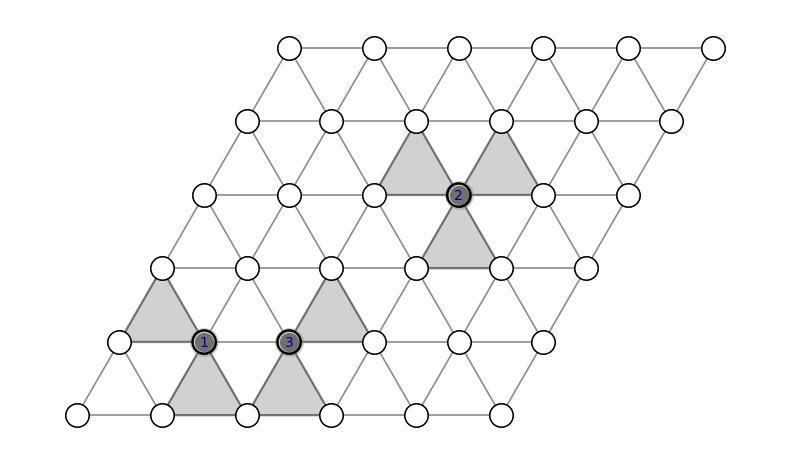

In [85]:
# example
# error_qubits = {(1, 0), (2, 0), (0, 1), (2, 1), (3, 1), (0, 2), (1, 2), (3, 2), (1, 3), (2, 3), }
s = 4
lat = pascal_mod2_rows(s, s)
lat = np.transpose(lat)
lat = lat[::-1]
lat = np.pad(lat, ((1, 1)), mode='constant', constant_values=0)
# error_qubits = bit_array_to_sites(lat, swap_rc_to_ij=True)
# violated_checks = {(s, 0), (s,s), (0,s)}

#custom example
error_qubits = {(1,1), (2, 1), (3,3)}
violated_checks = {(1,0), (2,0), (0,1), (2,1), (2, 3), (3, 3), (3,2)}

fig, ax = draw_nm(
    Lx=s+2,
    Ly=s+2,
    error_qubits=error_qubits,
    violated_checks=violated_checks,
    label=False,
)
plt.show()

In [25]:
print(np.pad(lat,(1,1)))

[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 1 1 1 1 0 0]
 [0 0 0 0 1 0 0 0 1 0 0]
 [0 0 0 1 1 0 0 1 1 0 0]
 [0 0 1 0 1 0 1 0 1 0 0]
 [0 1 1 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]
